<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 48px 40px; border-radius: 16px; margin-bottom: 8px;">
  <p style="color:#a78bfa; font-size:13px; letter-spacing:3px; text-transform:uppercase; margin:0 0 12px 0; font-family:monospace;">EXPLORATORY DATA ANALYSIS</p>
  <h1 style="color:#ffffff; font-size:36px; font-weight:700; margin:0 0 12px 0; line-height:1.2;">Air Quality Index Analysis<br>in Bangladesh</h1>
  <p style="color:#94a3b8; font-size:15px; margin:0 0 28px 0; max-width:600px; line-height:1.6;">A longitudinal study of pollution trends across 13 cities from 2014–2022, examining seasonal patterns, urban disparities, and the environmental impact of COVID-19 lockdowns.</p>
  <div style="display:flex; gap:24px; flex-wrap:wrap;">
    <span style="background:rgba(167,139,250,0.15); color:#a78bfa; padding:6px 16px; border-radius:20px; font-size:13px; border:1px solid rgba(167,139,250,0.3);">📍 13 Cities</span>
    <span style="background:rgba(167,139,250,0.15); color:#a78bfa; padding:6px 16px; border-radius:20px; font-size:13px; border:1px solid rgba(167,139,250,0.3);">📅 2014 – 2022</span>
    <span style="background:rgba(167,139,250,0.15); color:#a78bfa; padding:6px 16px; border-radius:20px; font-size:13px; border:1px solid rgba(167,139,250,0.3);">📊 ~21,000 Records</span>
    <span style="background:rgba(167,139,250,0.15); color:#a78bfa; padding:6px 16px; border-radius:20px; font-size:13px; border:1px solid rgba(167,139,250,0.3);">🐍 Python · Pandas · Seaborn</span>
  </div>
</div>

## 📌 Background & Context

Bangladesh is consistently ranked among the most air-polluted countries in the world. Rapid urbanization, industrial growth, brick kilns, and vehicle emissions have made cities like Dhaka and Rangpur hotspots for particulate matter.

The **Air Quality Index (AQI)** is a standardized scale that communicates how polluted the air is and what health effects may be of concern. It is calculated from key pollutants including PM2.5, PM10, NO₂, SO₂, CO, and O₃.

| AQI Range | Category | Health Implication |
|-----------|----------|--------------------|
| 0 – 50 | 🟢 Good | Air quality is satisfactory |
| 51 – 100 | 🟡 Moderate | Acceptable; some pollutants may concern sensitive people |
| 101 – 150 | 🟠 Unhealthy for Sensitive Groups | Sensitive groups may experience effects |
| 151 – 200 | 🔴 Unhealthy | Everyone may begin to experience effects |
| 201 – 300 | 🟣 Very Unhealthy | Health alert: serious effects for everyone |
| 301+ | 🟤 Hazardous | Emergency conditions; entire population affected |

> **Dataset Source:** Department of Environment (DoE), Bangladesh — daily AQI readings across major cities, collected via government monitoring stations.

## 📋 Table of Contents

1. [Setup & Configuration](#1)
2. [Data Loading & First Look](#2)
3. [Data Quality Assessment](#3)
4. [Data Cleaning](#4)
5. [Exploratory Data Analysis](#5)
   - 5.1 [Overview Statistics](#5-1)
   - 5.2 [AQI Category Distribution](#5-2)
   - 5.3 [City Rankings](#5-3)
   - 5.4 [Seasonal Patterns](#5-4)
   - 5.5 [Year-over-Year Trends](#5-5)
   - 5.6 [Time Series & COVID-19 Context](#5-6)
   - 5.7 [Proportion of Unhealthy Air Days](#5-7)
   - 5.8 [AQI Distribution by City](#5-8)
6. [Key Findings](#6)

## 1. Setup & Configuration <a id='1'></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── AQI Standard Color Palette ──────────────────────────────────────────────
AQI_COLORS = {
    'Good':                  '#2dc653',
    'Moderate':              '#f5c400',
    'Unhealthy (Sensitive)': '#ff7e00',
    'Unhealthy':             '#e8302a',
    'Very Unhealthy':        '#7d3c98',
    'Hazardous':             '#7e0023',
}
AQI_THRESHOLDS = [0, 50, 100, 150, 200, 300, 500]
AQI_LABELS     = list(AQI_COLORS.keys())
AQI_PALETTE    = list(AQI_COLORS.values())

# ── Visual Style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':   '#ffffff',
    'axes.facecolor':     '#f8f9fc',
    'axes.edgecolor':     '#dee2e6',
    'axes.labelcolor':    '#343a40',
    'axes.titlesize':     15,
    'axes.titleweight':   'bold',
    'axes.titlepad':      14,
    'axes.labelsize':     12,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'xtick.color':        '#6c757d',
    'ytick.color':        '#6c757d',
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'grid.color':         '#e9ecef',
    'grid.linewidth':     0.8,
    'legend.framealpha':  0.92,
    'legend.edgecolor':   '#dee2e6',
    'legend.fontsize':    10,
    'font.family':        'DejaVu Sans',
    'figure.dpi':         130,
})

PURPLE = '#6d28d9'
DARK   = '#1e293b'

def section_title(ax, title, subtitle=None):
    """Add a clean title + optional subtitle to an axes."""
    ax.set_title(title, fontsize=15, fontweight='bold', color=DARK, pad=14)
    if subtitle:
        ax.text(0.0, 1.015, subtitle, transform=ax.transAxes,
                fontsize=10, color='#64748b', va='bottom')

def categorize_aqi(aqi):
    if   aqi <= 50:  return 'Good'
    elif aqi <= 100: return 'Moderate'
    elif aqi <= 150: return 'Unhealthy (Sensitive)'
    elif aqi <= 200: return 'Unhealthy'
    elif aqi <= 300: return 'Very Unhealthy'
    else:            return 'Hazardous'

print("✅ Setup complete. AQI palette loaded.")

✅ Setup complete. AQI palette loaded.


## 2. Data Loading & First Look <a id='2'></a>

In [2]:
df_raw = pd.read_csv('case_data.csv')

print(f"Shape      : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Date range : {df_raw['Date'].iloc[0]}  →  {df_raw['Date'].iloc[-1]}")
print(f"Columns    : {list(df_raw.columns)}")
print()
df_raw.head(8)

Shape      : 26,251 rows × 5 columns
Date range : 05-08-2020  →  06-06-2022
Columns    : ['Date', 'LOCATION', 'Air Quality Index (AQI)', 'AQI CATEGORY', 'AQI RANGE']



,Date,LOCATION,Air Quality Index (AQI),AQI CATEGORY,AQI RANGE
0,05-08-2020,DHAKAc,25,GOOD,NaN
1,05-08-2020,GAZIPURc,DNA,DNA,NaN
2,05-08-2020,NARAYANGANJc,22,GOOD,NaN
3,05-08-2020,CHITTAGONGc,DNA,DNA,NaN
4,05-08-2020,SYLHETc,40,GOOD,NaN
5,05-08-2020,KHULNAc,DNA,DNA,NaN
6,05-08-2020,RAJSHAHIc,25,GOOD,NaN
7,05-08-2020,BARISHALc,DNA,DNA,NaN


In [3]:
# Quick column-level overview
print("=== Column Summary ===")
print(df_raw.info())
print()
print("=== AQI Category Value Counts (raw) ===")
print(df_raw['AQI CATEGORY'].value_counts(dropna=False).head(12))

=== Column Summary ===
<class 'pandas.DataFrame'>
RangeIndex: 26251 entries, 0 to 26250
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Date                     26238 non-null  str  
 1   LOCATION                 26202 non-null  str  
 2   Air Quality Index (AQI)  25610 non-null  str  
 3   AQI CATEGORY             26188 non-null  str  
 4   AQI RANGE                4216 non-null   str  
dtypes: str(5)
memory usage: 1.8 MB
None

=== AQI Category Value Counts (raw) ===
AQI CATEGORY
DNA                     5334
MODERATE                4723
GOOD                    3757
UNHEALTHY               3547
CAUTION                 3361
VERY UNHEALTHY          2829
EXTREMELY UNHEALTHY     2431
VERY UNHEALTHY            84
NaN                       63
EXTREMELY UNHEALTHY       42
DATA NOT AVAILABLE        20
EXETREMELY UNHEALTHY      18
Name: count, dtype: int64


## 3. Data Quality Assessment <a id='3'></a>

Before removing any rows, it's important to **understand the pattern of missing data**. Blind deletion can mask systematic sensor failures or data collection gaps.

Key issues found in the raw data:
- `AQI RANGE` column is entirely empty — redundant, safe to drop
- `Air Quality Index (AQI)` contains `'DNA'` strings (interpreted as missing) and true `NaN`s
- `LOCATION` contains **38 dirty variants** of just 13 city names (e.g. `'DHAKAc'`, `'Dhakaa'`, `'DhakaC'`, `'gongb'`)
- Dates are unsorted and stored as strings (`dd-mm-yyyy`)

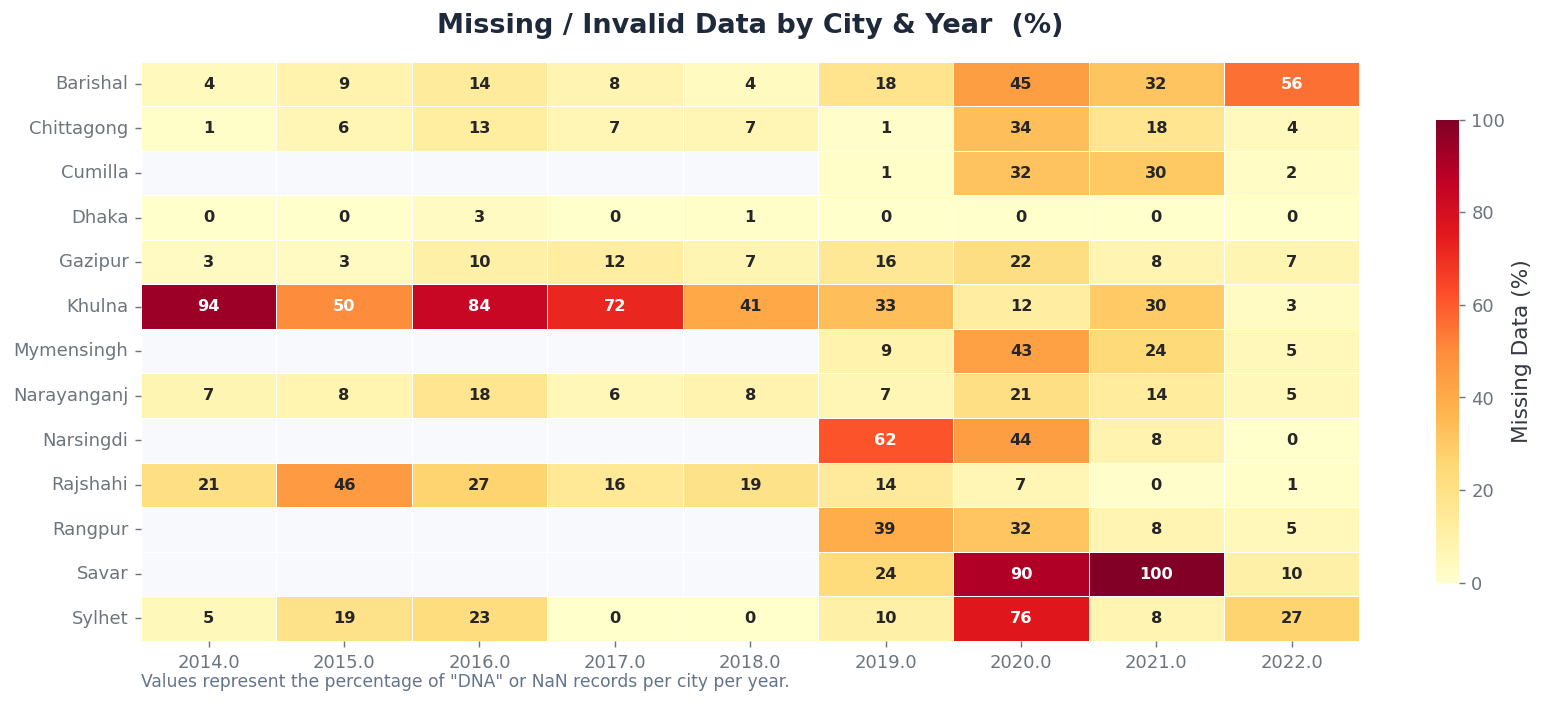


⚠️  Total missing/invalid records : 5,287  (20.1% of raw data)

💡 Notable: Khulna (94% in 2014), Savar (100% in 2021) — likely sensor outages, not true absence of pollution.


In [4]:
# ── Step 1: Standardise location names first so we can group by city ─────────
location_mapping = {
    'DHAKAc':'Dhaka','GAZIPURc':'Gazipur','NARAYANGANJc':'Narayanganj',
    'CHITTAGONGc':'Chittagong','SYLHETc':'Sylhet','KHULNAc':'Khulna',
    'RAJSHAHIc':'Rajshahi','BARISHALc':'Barishal','SAVARc':'Savar',
    'MYMENSINGHc':'Mymensingh','RANGPURc':'Rangpur','CUMILLAc':'Cumilla',
    'NARSINGDIc':'Narsingdi','Dhakaa':'Dhaka','Chittagongb':'Chittagong',
    'Gazipurc':'Gazipur','Narayanganjc':'Narayanganj','Sylhetcc':'Sylhet',
    'Khulnac':'Khulna','Rajshahic':'Rajshahi','Barisalc':'Barishal',
    'Sylhetc':'Sylhet','gongb':'Chittagong','Dhakac':'Dhaka',
    'Chittagongc':'Chittagong','Dhakab':'Dhaka','DhakaC':'Dhaka',
    'ChittagongC':'Chittagong','Sylhetc2':'Sylhet','DHAKAb':'Dhaka',
    'NARSINGDI':'Narsingdi','114AZIPURc':'Gazipur','CHITTAGONGb':'Chittagong',
    'SavarC':'Savar','MymensinghC':'Mymensingh','Rangpurc':'Rangpur',
    'Cumillac':'Cumilla','Narsingdic':'Narsingdi'
}

df_q = df_raw.copy()
df_q['LOCATION'] = df_q['LOCATION'].replace(location_mapping)
df_q['Date_parsed'] = pd.to_datetime(df_q['Date'], format='%d-%m-%Y', errors='coerce')
df_q['Year'] = df_q['Date_parsed'].dt.year
df_q['is_missing'] = (df_q['Air Quality Index (AQI)'] == 'DNA') | df_q['Air Quality Index (AQI)'].isna()

# ── Missing data heatmap ──────────────────────────────────────────────────────
miss_pct = (df_q.groupby(['LOCATION', 'Year'])['is_missing']
              .mean()
              .unstack(fill_value=np.nan) * 100)

fig, ax = plt.subplots(figsize=(13, 5.5))
fig.patch.set_facecolor('#ffffff')

sns.heatmap(
    miss_pct,
    ax=ax,
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='#ffffff',
    annot=True,
    fmt='.0f',
    annot_kws={'size': 9, 'weight': 'bold'},
    cbar_kws={'label': 'Missing Data (%)', 'shrink': 0.8},
    vmin=0, vmax=100
)

ax.set_title('Missing / Invalid Data by City & Year  (%)', fontsize=15, fontweight='bold',
             color='#1e293b', pad=16)
ax.text(0, -0.08, 'Values represent the percentage of "DNA" or NaN records per city per year.',
        transform=ax.transAxes, fontsize=9.5, color='#64748b')
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('missing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

total_missing = df_q['is_missing'].sum()
print(f"\n⚠️  Total missing/invalid records : {total_missing:,}  ({total_missing/len(df_q)*100:.1f}% of raw data)")
print("\n💡 Notable: Khulna (94% in 2014), Savar (100% in 2021) — likely sensor outages, not true absence of pollution.")

## 4. Data Cleaning <a id='4'></a>

With the missing data pattern understood, we now apply a structured cleaning pipeline:

1. **Drop `AQI RANGE`** — column is entirely empty
2. **Drop `AQI CATEGORY`** — will be reconstructed from AQI values using WHO standard thresholds
3. **Standardise location names** (38 dirty variants → 13 clean city names)
4. **Remove `DNA` and `NaN` records** — confirmed as genuine sensor failures
5. **Parse and sort dates** (`dd-mm-yyyy` strings → `datetime`)
6. **Convert AQI to numeric** and remove invalid zeros
7. **Reconstruct AQI category** using WHO standard brackets + standard colors

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# CLEANING PIPELINE
# ═══════════════════════════════════════════════════════════════════════════════

df = df_raw.copy()

# Step 1 & 2: Drop empty/redundant columns
df = df.drop(columns=['AQI RANGE', 'AQI CATEGORY'])

# Step 3: Standardise location names
df['LOCATION'] = df['LOCATION'].replace(location_mapping)

# Step 4: Remove DNA and NaN rows
df = df.dropna(subset=['Air Quality Index (AQI)'])
df = df[df['Air Quality Index (AQI)'] != 'DNA']

# Step 5: Parse and sort dates
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')
df = df.dropna(subset=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Step 6: Convert AQI to numeric; drop zeros and coercion failures
df.rename(columns={'LOCATION': 'City', 'Air Quality Index (AQI)': 'AQI'}, inplace=True)
df['AQI'] = pd.to_numeric(df['AQI'], errors='coerce')
df = df.dropna(subset=['AQI'])
df = df[df['AQI'] > 0]

# Step 7: Add derived columns
df['Category'] = df['AQI'].apply(categorize_aqi)
df['Month']    = df['Date'].dt.month
df['Year']     = df['Date'].dt.year
df['Month_Name'] = df['Date'].dt.strftime('%b')

# ── Summary ──────────────────────────────────────────────────────────────────
print("═" * 50)
print("  CLEANING SUMMARY")
print("═" * 50)
print(f"  Raw records        : {len(df_raw):>7,}")
print(f"  After cleaning     : {len(df):>7,}  ({len(df)/len(df_raw)*100:.1f}% retained)")
print(f"  Records removed    : {len(df_raw)-len(df):>7,}")
print(f"  Cities             : {df['City'].nunique()}")
print(f"  Date range         : {df['Date'].min().date()}  →  {df['Date'].max().date()}")
print(f"  AQI mean           : {df['AQI'].mean():.1f}")
print(f"  AQI median         : {df['AQI'].median():.1f}")
print(f"  AQI max            : {df['AQI'].max():.0f}")
print("═" * 50)
df.head(6)

══════════════════════════════════════════════════
  CLEANING SUMMARY
══════════════════════════════════════════════════
  Raw records        :  26,251
  After cleaning     :  20,831  (79.4% retained)
  Records removed    :   5,420
  Cities             : 13
  Date range         : 2014-02-17  →  2022-06-08
  AQI mean           : 149.1
  AQI median         : 126.0
  AQI max            : 821
══════════════════════════════════════════════════


,Date,City,AQI,Category,Month,Year,Month_Name
0,2014-02-17,Dhaka,172.0,Unhealthy,2,2014,Feb
1,2014-02-17,Chittagong,125.0,Unhealthy (Sensitive),2,2014,Feb
2,2014-02-17,Gazipur,178.0,Unhealthy,2,2014,Feb
3,2014-02-17,Narayanganj,174.0,Unhealthy,2,2014,Feb
4,2014-02-17,Sylhet,129.0,Unhealthy (Sensitive),2,2014,Feb
5,2014-02-17,Rajshahi,118.0,Unhealthy (Sensitive),2,2014,Feb


## 5. Exploratory Data Analysis <a id='5'></a>

### 5.1 Overview Statistics <a id='5-1'></a>

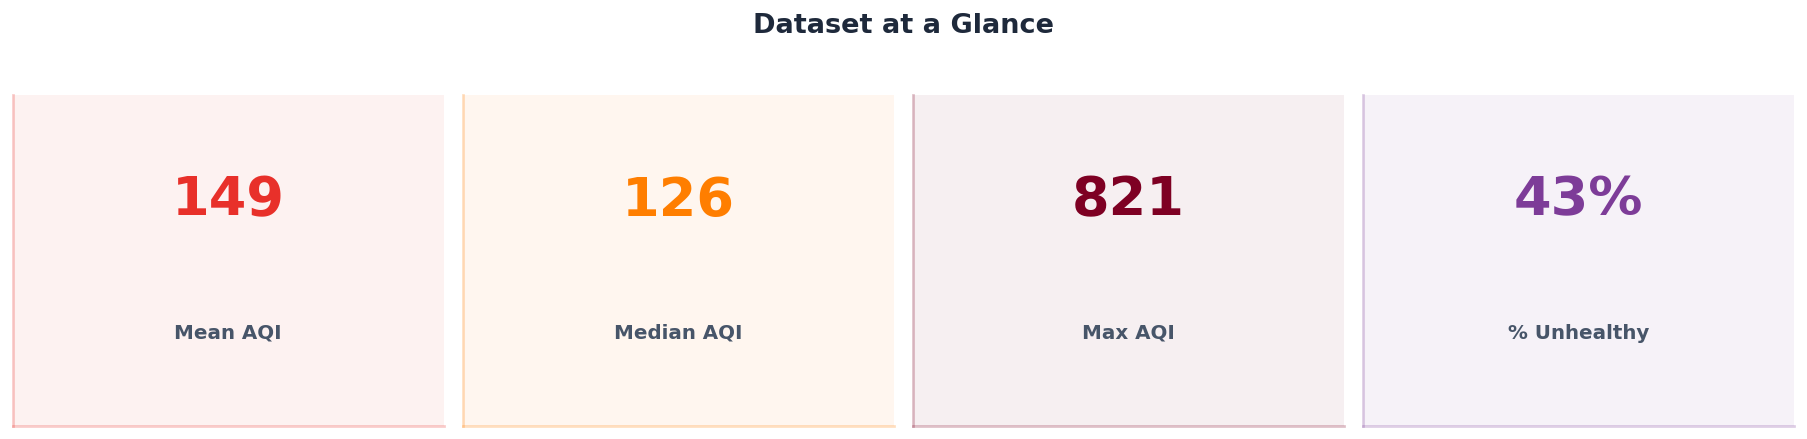

,count,mean,std,min,25%,50%,75%,max
AQI Statistics,20831.0,149.1,103.1,3.0,64.0,126.0,207.0,821.0


In [6]:
# ── Key Stats Banner ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
fig.patch.set_facecolor('#ffffff')

stats = [
    ('Mean AQI',    f"{df['AQI'].mean():.0f}",       '🏭', '#e8302a'),
    ('Median AQI',  f"{df['AQI'].median():.0f}",      '📊', '#ff7e00'),
    ('Max AQI',     f"{df['AQI'].max():.0f}",          '⚠️',  '#7e0023'),
    ('% Unhealthy', f"{len(df[df['AQI']>150])/len(df)*100:.0f}%", '😷', '#7d3c98'),
]

for ax, (label, value, icon, color) in zip(axes, stats):
    ax.set_facecolor(color + '10')
    for spine in ax.spines.values():
        spine.set_edgecolor(color + '40')
        spine.set_linewidth(1.5)
    ax.text(0.5, 0.68, value, transform=ax.transAxes, fontsize=30,
            fontweight='bold', ha='center', va='center', color=color)
    ax.text(0.5, 0.28, label, transform=ax.transAxes, fontsize=11,
            ha='center', va='center', color='#475569', fontweight='600')
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle('Dataset at a Glance', fontsize=15, fontweight='bold', color=DARK, y=1.04)
plt.tight_layout()
plt.savefig('overview_stats.png', dpi=150, bbox_inches='tight')
plt.show()

# Detailed describe
df['AQI'].describe().rename('AQI Statistics').to_frame().T.round(1)

### 5.2 AQI Category Distribution <a id='5-2'></a>

How often does the air quality fall into each WHO category across all cities and years?

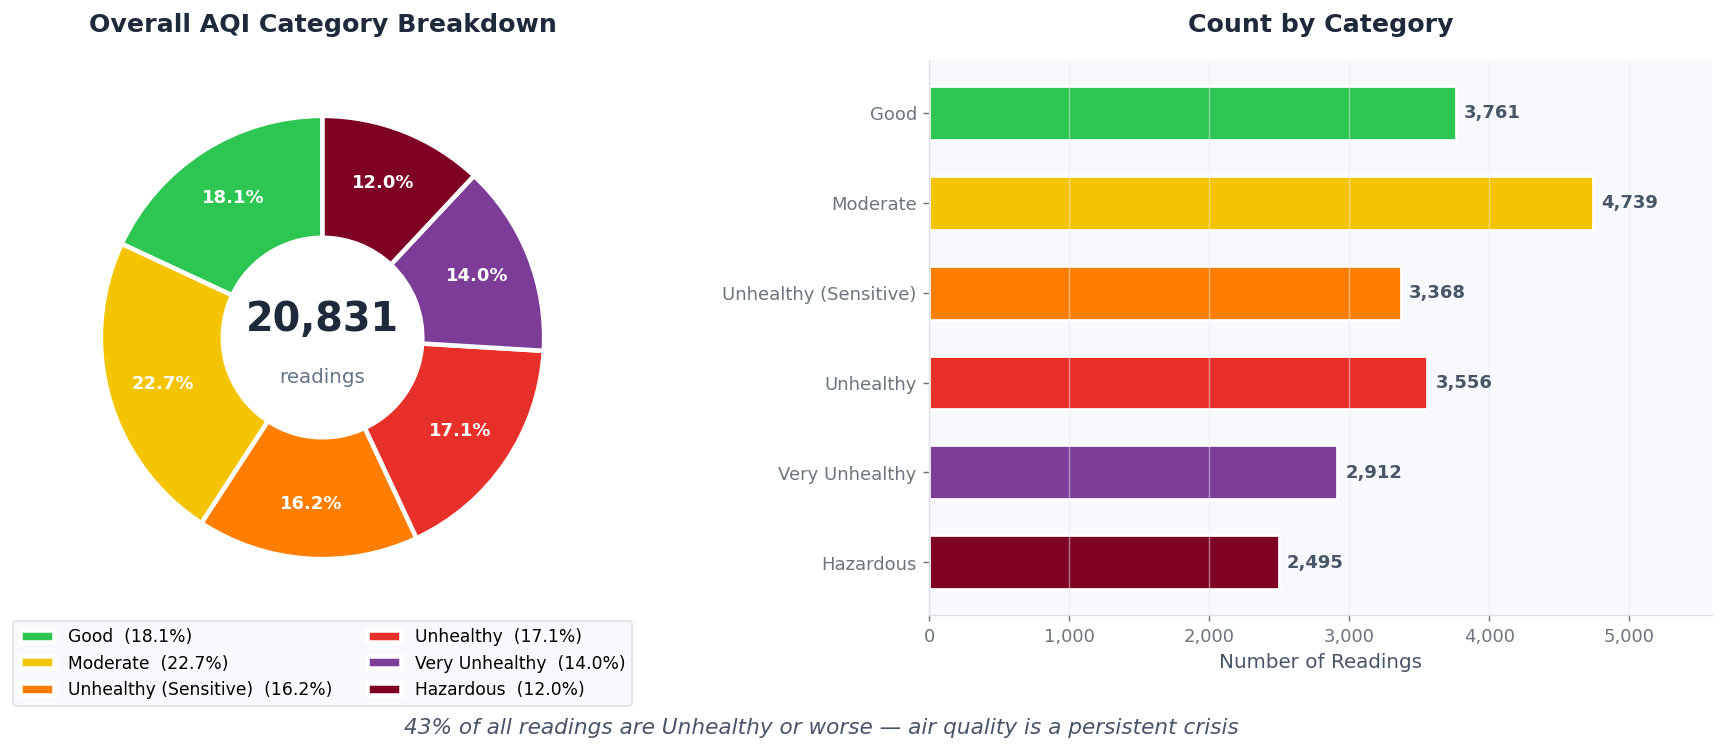

In [7]:
cat_counts = df['Category'].value_counts().reindex(AQI_LABELS).dropna()
cat_pcts   = cat_counts / cat_counts.sum() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#ffffff')

# ── Donut chart ───────────────────────────────────────────────────────────────
colors_ordered = [AQI_COLORS[c] for c in cat_counts.index]
wedges, texts, autotexts = ax1.pie(
    cat_counts,
    labels=None,
    colors=colors_ordered,
    autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'linewidth': 2.5, 'edgecolor': 'white', 'width': 0.55},
)
for t in autotexts:
    t.set_fontsize(10); t.set_fontweight('bold'); t.set_color('white')

# Centre annotation
ax1.text(0, 0.08, f"{len(df):,}", ha='center', va='center',
         fontsize=22, fontweight='bold', color=DARK)
ax1.text(0, -0.18, "readings", ha='center', va='center',
         fontsize=11, color='#64748b')

ax1.legend(
    wedges, [f"{c}  ({cat_pcts[c]:.1f}%)" for c in cat_counts.index],
    loc='lower center', bbox_to_anchor=(0.5, -0.18),
    ncol=2, fontsize=9.5, framealpha=0.9
)
ax1.set_title('Overall AQI Category Breakdown', fontsize=14, fontweight='bold', color=DARK, pad=16)

# ── Horizontal bar ────────────────────────────────────────────────────────────
bars = ax2.barh(cat_counts.index[::-1], cat_counts.values[::-1],
                color=[AQI_COLORS[c] for c in cat_counts.index[::-1]],
                height=0.6, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, cat_counts.values[::-1]):
    ax2.text(bar.get_width() + 60, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=10, color='#475569', fontweight='600')

ax2.set_xlabel('Number of Readings', fontsize=11, color='#475569')
ax2.set_title('Count by Category', fontsize=14, fontweight='bold', color=DARK, pad=16)
ax2.set_xlim(0, cat_counts.max() * 1.18)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.set_facecolor('#f8f9fc')
ax2.grid(axis='x', alpha=0.5)

fig.suptitle(
    f"43% of all readings are Unhealthy or worse — air quality is a persistent crisis",
    fontsize=12, color='#475569', y=0.02, style='italic'
)
plt.tight_layout()
plt.savefig('category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 City Rankings <a id='5-3'></a>

Which cities are breathing the cleanest — and the most dangerous — air?

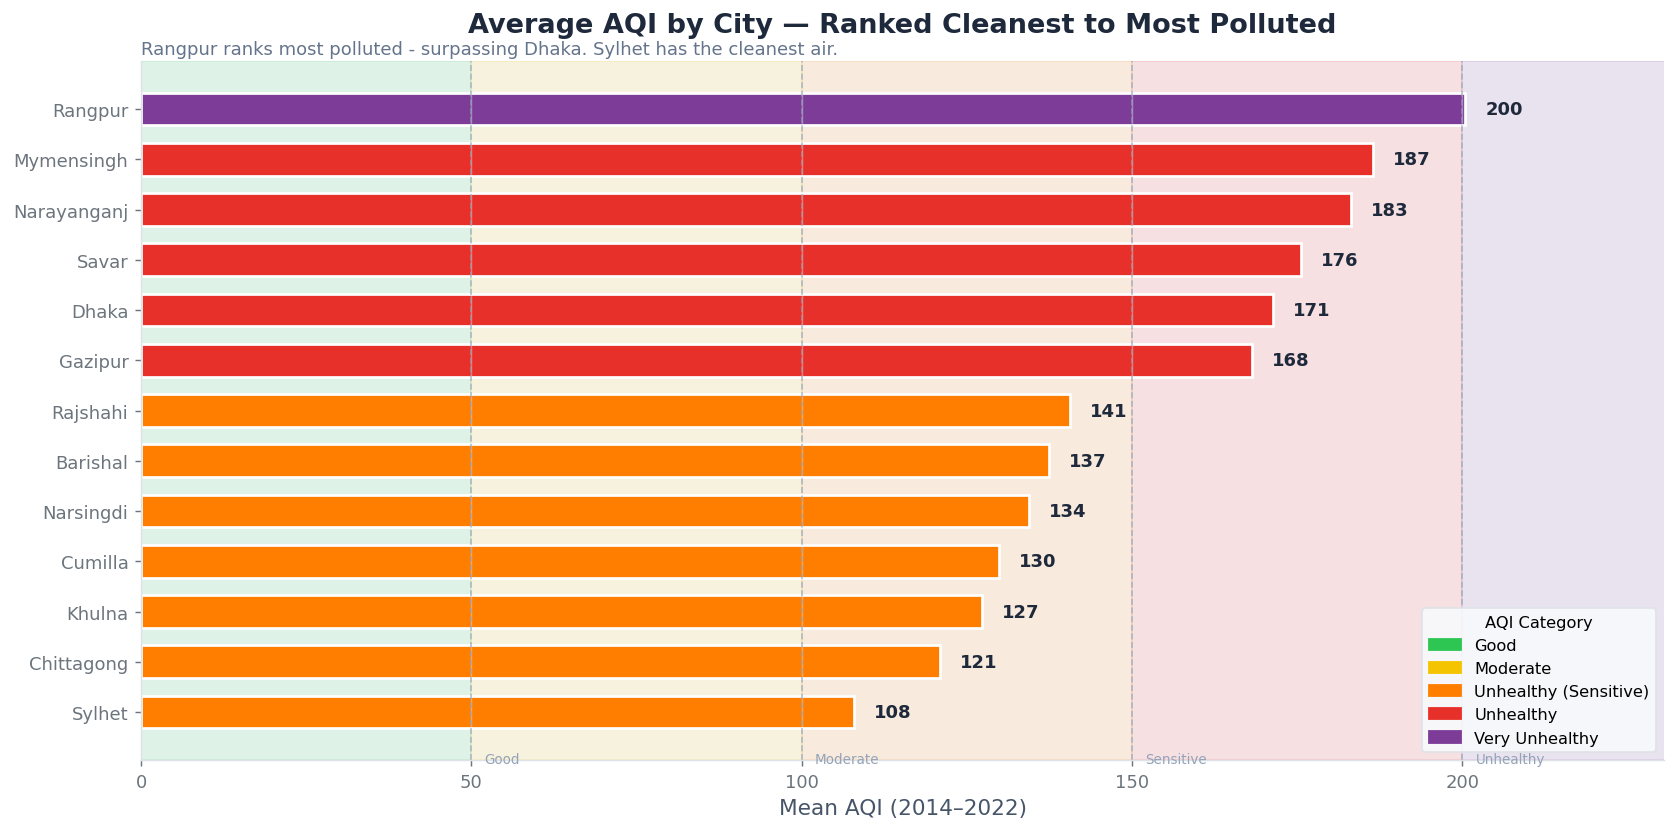

In [8]:
city_stats = df.groupby('City').agg(
    Mean_AQI=('AQI', 'mean'),
    Median_AQI=('AQI', 'median'),
    Max_AQI=('AQI', 'max'),
    Count=('AQI', 'count')
).sort_values('Mean_AQI', ascending=True).reset_index()

city_stats['Category'] = city_stats['Mean_AQI'].apply(categorize_aqi)
city_stats['Color']    = city_stats['Category'].map(AQI_COLORS)

fig, ax = plt.subplots(figsize=(13, 6.5))
fig.patch.set_facecolor('#ffffff')

bars = ax.barh(city_stats['City'], city_stats['Mean_AQI'],
               color=city_stats['Color'], height=0.65,
               edgecolor='white', linewidth=1.5)

# Add WHO threshold bands
threshold_colors = ['#2dc65320', '#f5c40020', '#ff7e0020', '#e8302a20', '#7d3c9820']
threshold_labels = [50, 100, 150, 200, 300]
for i, (lo, hi) in enumerate(zip([0,50,100,150,200], [50,100,150,200,350])):
    ax.axvspan(lo, hi, alpha=0.12, color=AQI_PALETTE[i], zorder=0)

# Vertical threshold lines
for thresh, label in zip([50, 100, 150, 200], ['Good', 'Moderate', 'Sensitive', 'Unhealthy']):
    ax.axvline(thresh, color='#94a3b8', linestyle='--', linewidth=0.9, alpha=0.7)
    ax.text(thresh+2, -0.8, label, fontsize=7.5, color='#94a3b8', va='top', rotation=0)

# Value labels
for bar, row in zip(bars, city_stats.itertuples()):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'{row.Mean_AQI:.0f}', va='center', fontsize=10,
            fontweight='bold', color='#1e293b')

ax.set_xlabel('Mean AQI (2014–2022)', fontsize=12, color='#475569')
ax.set_title('Average AQI by City — Ranked Cleanest to Most Polluted',
             fontsize=15, fontweight='bold', color=DARK, pad=16)
ax.text(0, 1.01,
        'Rangpur ranks most polluted - surpassing Dhaka. Sylhet has the cleanest air.',
        transform=ax.transAxes, fontsize=10, color='#64748b')
ax.set_xlim(0, city_stats['Mean_AQI'].max() * 1.15)
ax.set_facecolor('#f8f9fc')
ax.grid(axis='x', alpha=0.4)

# Legend
legend_patches = [mpatches.Patch(color=AQI_COLORS[c], label=c) for c in AQI_LABELS[:5]]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9, title='AQI Category', title_fontsize=9)

plt.tight_layout()
plt.savefig('city_rankings.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Seasonal Patterns <a id='5-4'></a>

Bangladesh's air quality is **strongly seasonal**. The dry winter months (October–March) trap pollutants near the surface, while the monsoon season (June–September) clears the air dramatically.

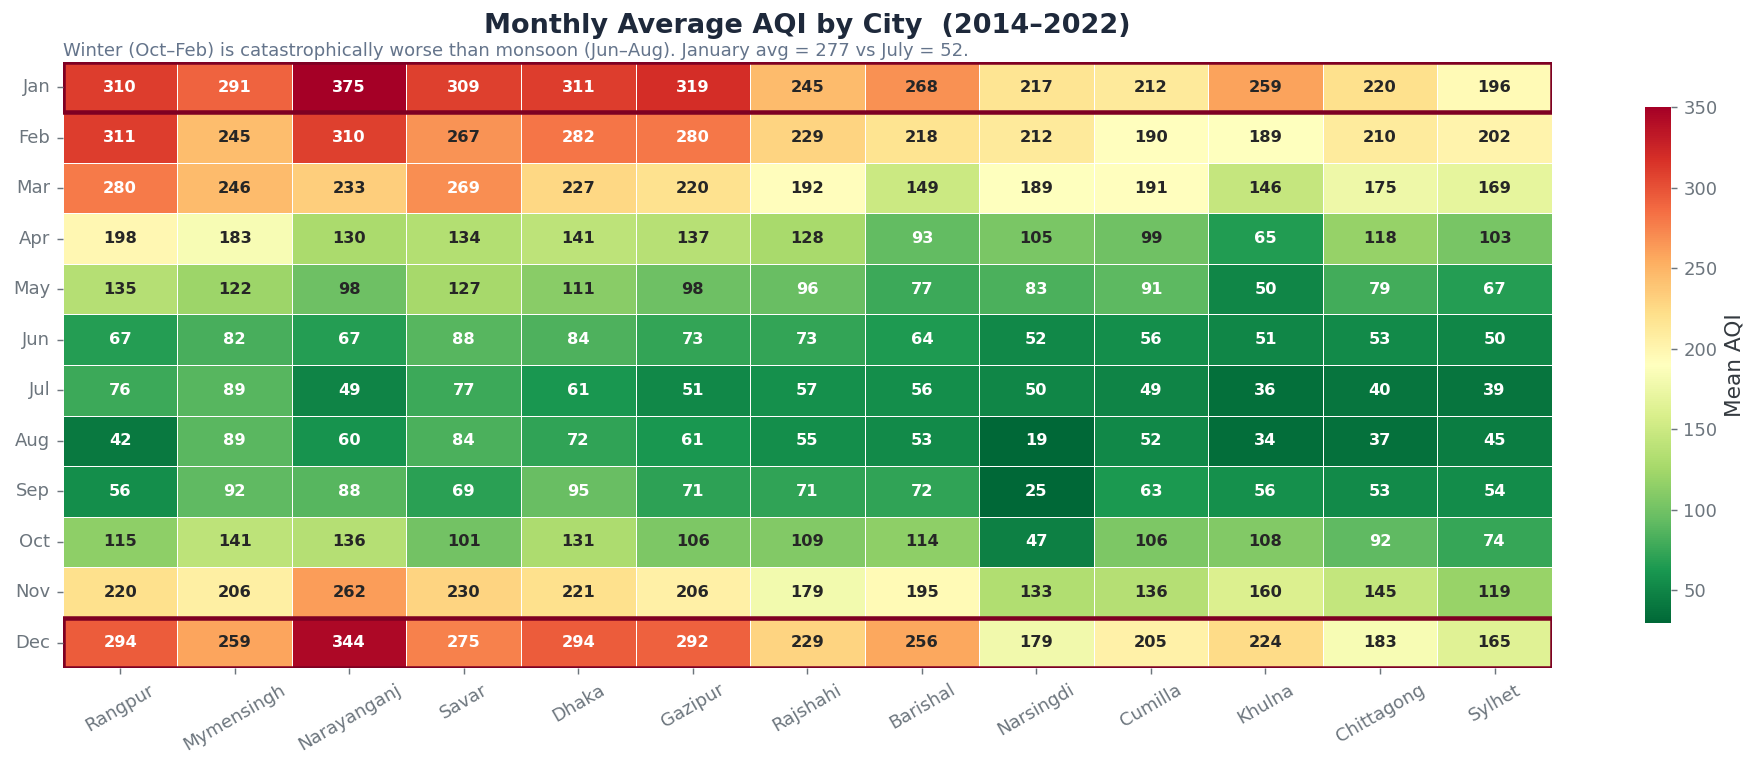

In [9]:
month_city = df.pivot_table(values='AQI', index='Month', columns='City', aggfunc='mean')
month_city.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Sort cities by annual mean
city_order = df.groupby('City')['AQI'].mean().sort_values(ascending=False).index
month_city = month_city[city_order]

fig, ax = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor('#ffffff')

sns.heatmap(
    month_city,
    ax=ax,
    cmap='RdYlGn_r',
    linewidths=0.4,
    linecolor='#ffffff',
    annot=True,
    fmt='.0f',
    annot_kws={'size': 9, 'weight': 'bold'},
    cbar_kws={'label': 'Mean AQI', 'shrink': 0.85},
    vmin=30, vmax=350
)

ax.set_title('Monthly Average AQI by City  (2014–2022)',
             fontsize=15, fontweight='bold', color=DARK, pad=16)
ax.text(0, 1.01,
        'Winter (Oct–Feb) is catastrophically worse than monsoon (Jun–Aug). January avg = 277 vs July = 52.',
        transform=ax.transAxes, fontsize=10, color='#64748b')
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

# Highlight worst row
for i, month in enumerate(month_city.index):
    if month in ['Jan', 'Dec']:
        ax.add_patch(plt.Rectangle((0, i), len(city_order), 1,
                                   fill=False, edgecolor='#7e0023', lw=2.5))

plt.tight_layout()
plt.savefig('seasonal_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 Year-over-Year Trends <a id='5-5'></a>

How has air quality evolved across the 9-year period? Is it getting better or worse?

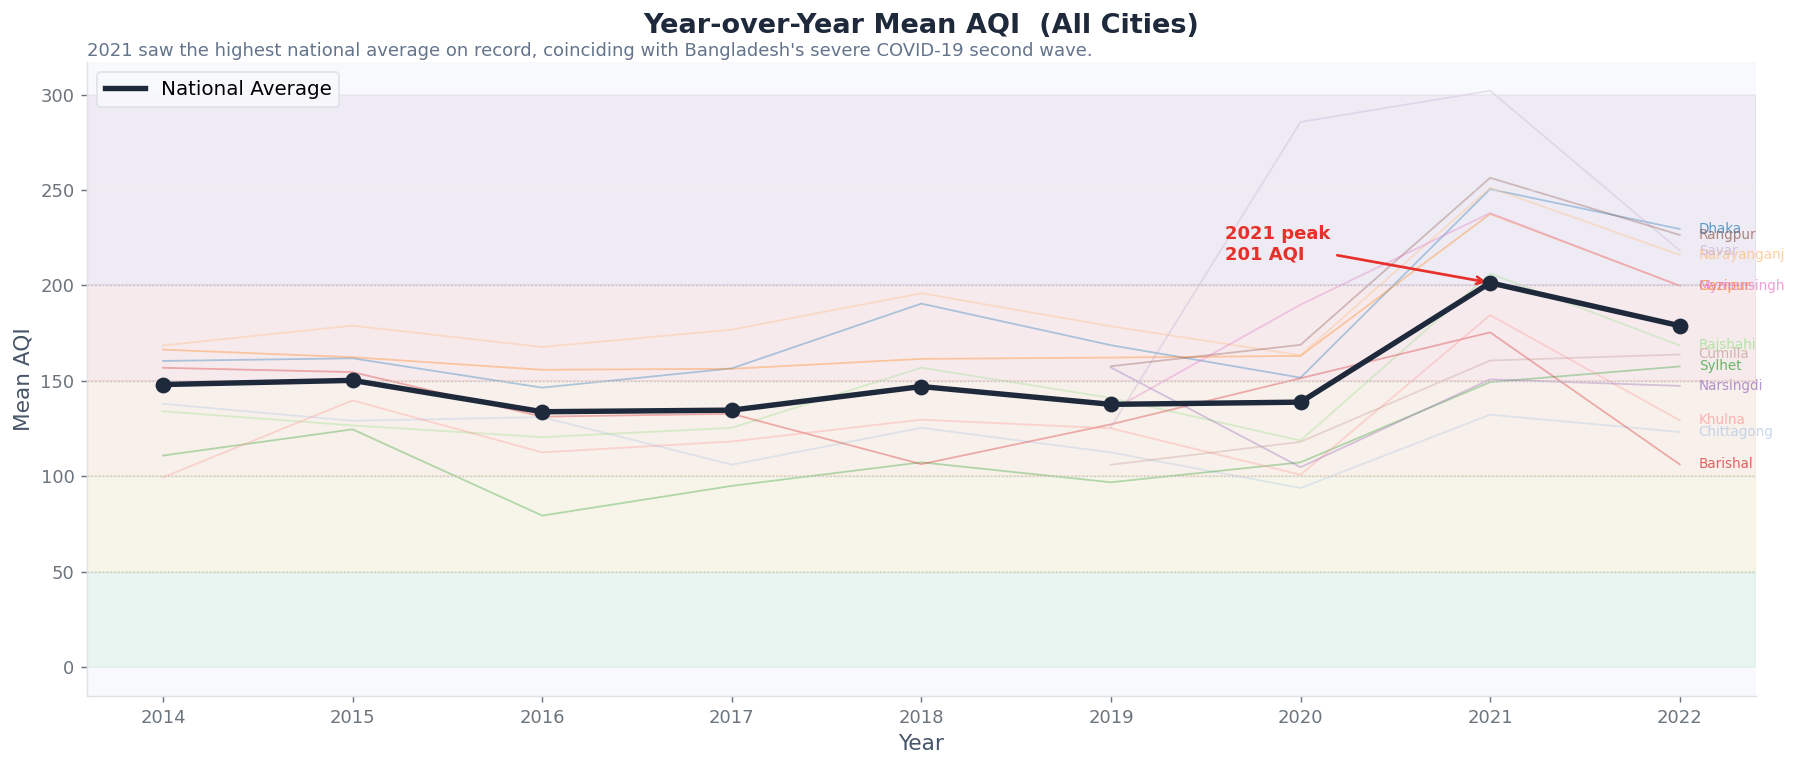

In [10]:
yearly = df.groupby(['Year', 'City'])['AQI'].mean().reset_index()
yearly_nat = df.groupby('Year')['AQI'].mean().reset_index()

top5 = df.groupby('City')['AQI'].mean().nlargest(5).index
bot5 = df.groupby('City')['AQI'].mean().nsmallest(5).index

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#ffffff')

# Background category bands
for lo, hi, color in zip([0,50,100,150,200],[50,100,150,200,300], AQI_PALETTE):
    ax.axhspan(lo, hi, alpha=0.07, color=color, zorder=0)

# Individual cities (thin, muted)
palette = sns.color_palette('tab20', n_colors=df['City'].nunique())
for idx, city in enumerate(df['City'].unique()):
    d = yearly[yearly['City'] == city]
    ax.plot(d['Year'], d['AQI'], color=palette[idx], linewidth=1,
            alpha=0.35, zorder=1)
    # Label at last point
    last = d.iloc[-1]
    ax.text(last['Year'] + 0.1, last['AQI'], city,
            fontsize=7.5, color=palette[idx], alpha=0.7, va='center')

# National average — bold
ax.plot(yearly_nat['Year'], yearly_nat['AQI'],
        color=DARK, linewidth=3, zorder=5, label='National Average')
ax.scatter(yearly_nat['Year'], yearly_nat['AQI'],
           color=DARK, s=60, zorder=6)

# Annotate 2021 spike
worst_year = yearly_nat.loc[yearly_nat['AQI'].idxmax()]
ax.annotate('2021 peak\n' + f"{worst_year['AQI']:.0f} AQI",
            xy=(worst_year['Year'], worst_year['AQI']),
            xytext=(worst_year['Year']-1.4, worst_year['AQI']+12),
            fontsize=10, color='#e8302a', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#e8302a', lw=1.5))

ax.set_title('Year-over-Year Mean AQI  (All Cities)',
             fontsize=15, fontweight='bold', color=DARK, pad=16)
ax.text(0, 1.01, "2021 saw the highest national average on record, coinciding with Bangladesh's severe COVID-19 second wave.",
        transform=ax.transAxes, fontsize=10, color='#64748b')
ax.set_xlabel('Year', fontsize=12, color='#475569')
ax.set_ylabel('Mean AQI', fontsize=12, color='#475569')
ax.set_xticks(yearly_nat['Year'].unique())
ax.set_facecolor('#f8f9fc')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)

# WHO threshold labels on right
for val, label in [(50,'Good'), (100,'Moderate'), (150,'Sensitive'), (200,'Unhealthy')]:
    ax.axhline(val, color='#94a3b8', linestyle=':', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig('yearly_trends.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.6 Time Series & COVID-19 Context <a id='5-6'></a>

Bangladesh imposed strict lockdowns in **April–June 2020** and **April–June 2021**. We examine whether these restrictions had any measurable effect on air quality in Dhaka, the capital.

A 30-day rolling average is applied to smooth daily noise and reveal the underlying trend.

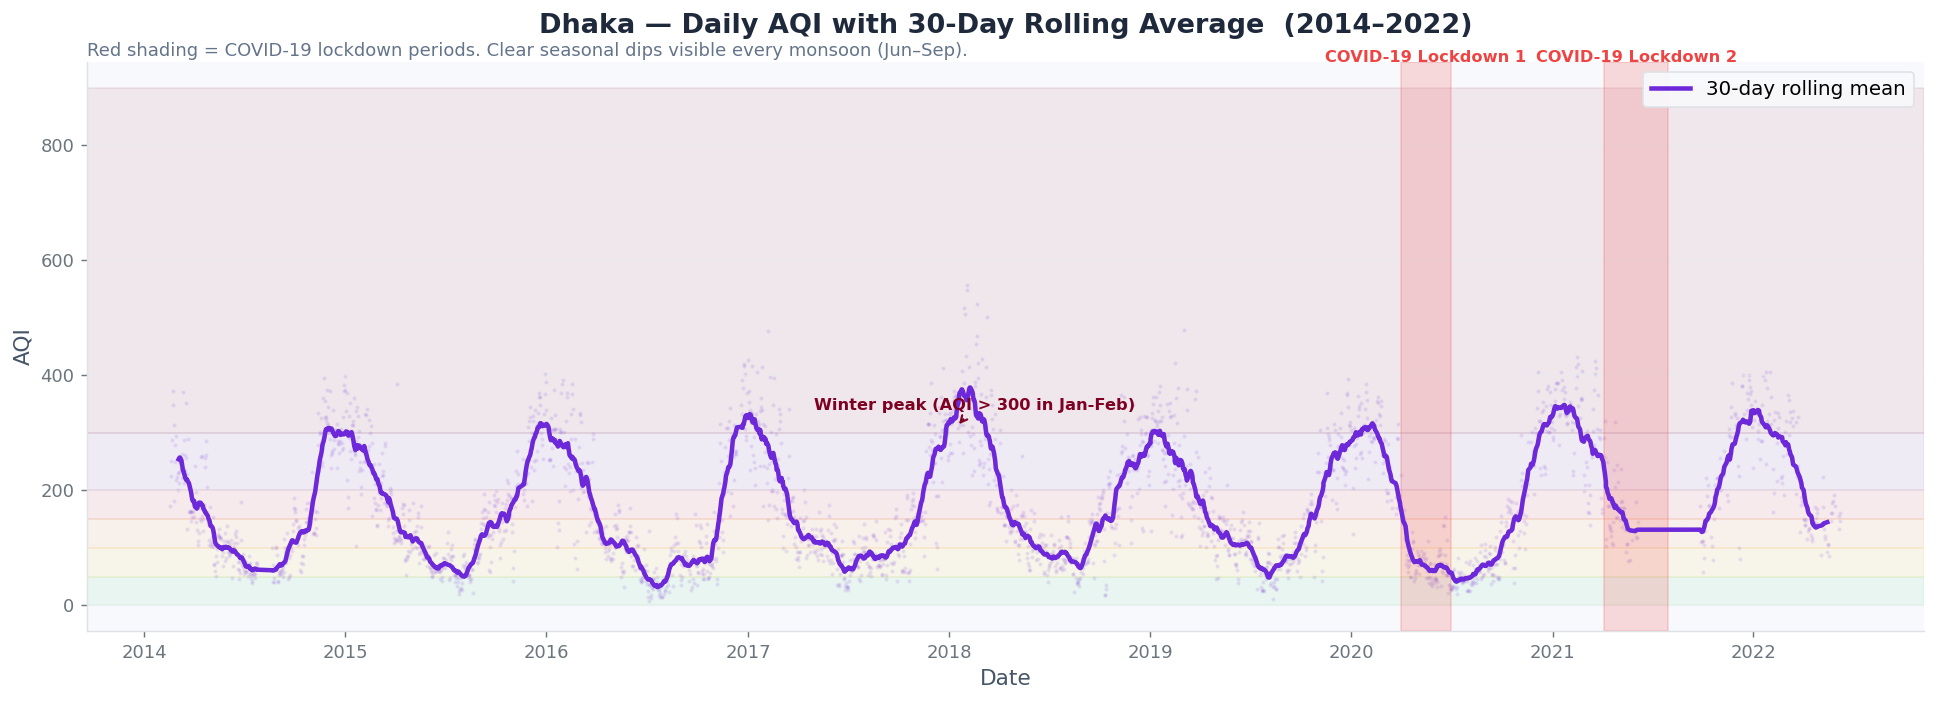

Dhaka AQI — Pre-lockdown baseline (2019):     168.7
Dhaka AQI — Lockdown 1 (Apr–Jun 2020):        77.5  (-54.1% vs 2019)
Dhaka AQI — Lockdown 2 (Apr–Jun 2021):        165.5  (-1.9% vs 2019)
Dhaka AQI — 2022 average:                     229.6


In [11]:
dhaka = df[df['City'] == 'Dhaka'].set_index('Date').sort_index()
dhaka['Rolling30'] = dhaka['AQI'].rolling(30, center=True).mean()

fig, ax = plt.subplots(figsize=(15, 5.5))
fig.patch.set_facecolor('#ffffff')

# AQI category shading
for lo, hi, color in zip([0,50,100,150,200,300],[50,100,150,200,300,900], AQI_PALETTE):
    ax.axhspan(lo, hi, alpha=0.07, color=color, zorder=0)

# Daily readings — very transparent
ax.scatter(dhaka.index, dhaka['AQI'], color='#6d28d9', alpha=0.08, s=2, zorder=1)

# 30-day rolling average
ax.plot(dhaka.index, dhaka['Rolling30'], color='#6d28d9', linewidth=2.5, zorder=3,
        label='30-day rolling mean')

# COVID lockdown shading
import matplotlib.dates as mdates
lockdowns = [
    ('2020-04-01', '2020-06-30', 'COVID-19 Lockdown 1'),
    ('2021-04-05', '2021-07-30', 'COVID-19 Lockdown 2'),
]
for start, end, label in lockdowns:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               alpha=0.18, color='#ef4444', zorder=2)
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax.text(mid, ax.get_ylim()[1] if ax.get_ylim()[1] > 200 else 260,
            label, ha='center', fontsize=9, color='#ef4444', fontweight='bold')

# Winter peaks annotation
ax.annotate('Winter peak (AQI > 300 in Jan-Feb)',
            xy=(pd.Timestamp('2018-01-15'), 310),
            xytext=(pd.Timestamp('2017-05-01'), 340),
            fontsize=9, color='#7e0023', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#7e0023', lw=1.2))

ax.set_title('Dhaka — Daily AQI with 30-Day Rolling Average  (2014–2022)',
             fontsize=15, fontweight='bold', color=DARK, pad=16)
ax.text(0, 1.01,
        'Red shading = COVID-19 lockdown periods. Clear seasonal dips visible every monsoon (Jun–Sep).',
        transform=ax.transAxes, fontsize=10, color='#64748b')
ax.set_ylabel('AQI', fontsize=12, color='#475569')
ax.set_xlabel('Date', fontsize=12, color='#475569')
ax.set_facecolor('#f8f9fc')
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', alpha=0.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.savefig('dhaka_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

# Lockdown comparison
pre  = dhaka[dhaka.index.year == 2019]['AQI'].mean()
ld1  = dhaka['2020-04-01':'2020-06-30']['AQI'].mean()
ld2  = dhaka['2021-04-01':'2021-06-30']['AQI'].mean()
post = dhaka[dhaka.index.year == 2022]['AQI'].mean()
print(f"Dhaka AQI — Pre-lockdown baseline (2019):     {pre:.1f}")
print(f"Dhaka AQI — Lockdown 1 (Apr–Jun 2020):        {ld1:.1f}  ({((ld1-pre)/pre*100):+.1f}% vs 2019)")
print(f"Dhaka AQI — Lockdown 2 (Apr–Jun 2021):        {ld2:.1f}  ({((ld2-pre)/pre*100):+.1f}% vs 2019)")
print(f"Dhaka AQI — 2022 average:                     {post:.1f}")

### 5.7 Proportion of Unhealthy Air Days <a id='5-7'></a>

Mean AQI can be misleading — a city could have moderate average AQI but still have many dangerous spike days. Here we look at what fraction of days exceed each WHO threshold.

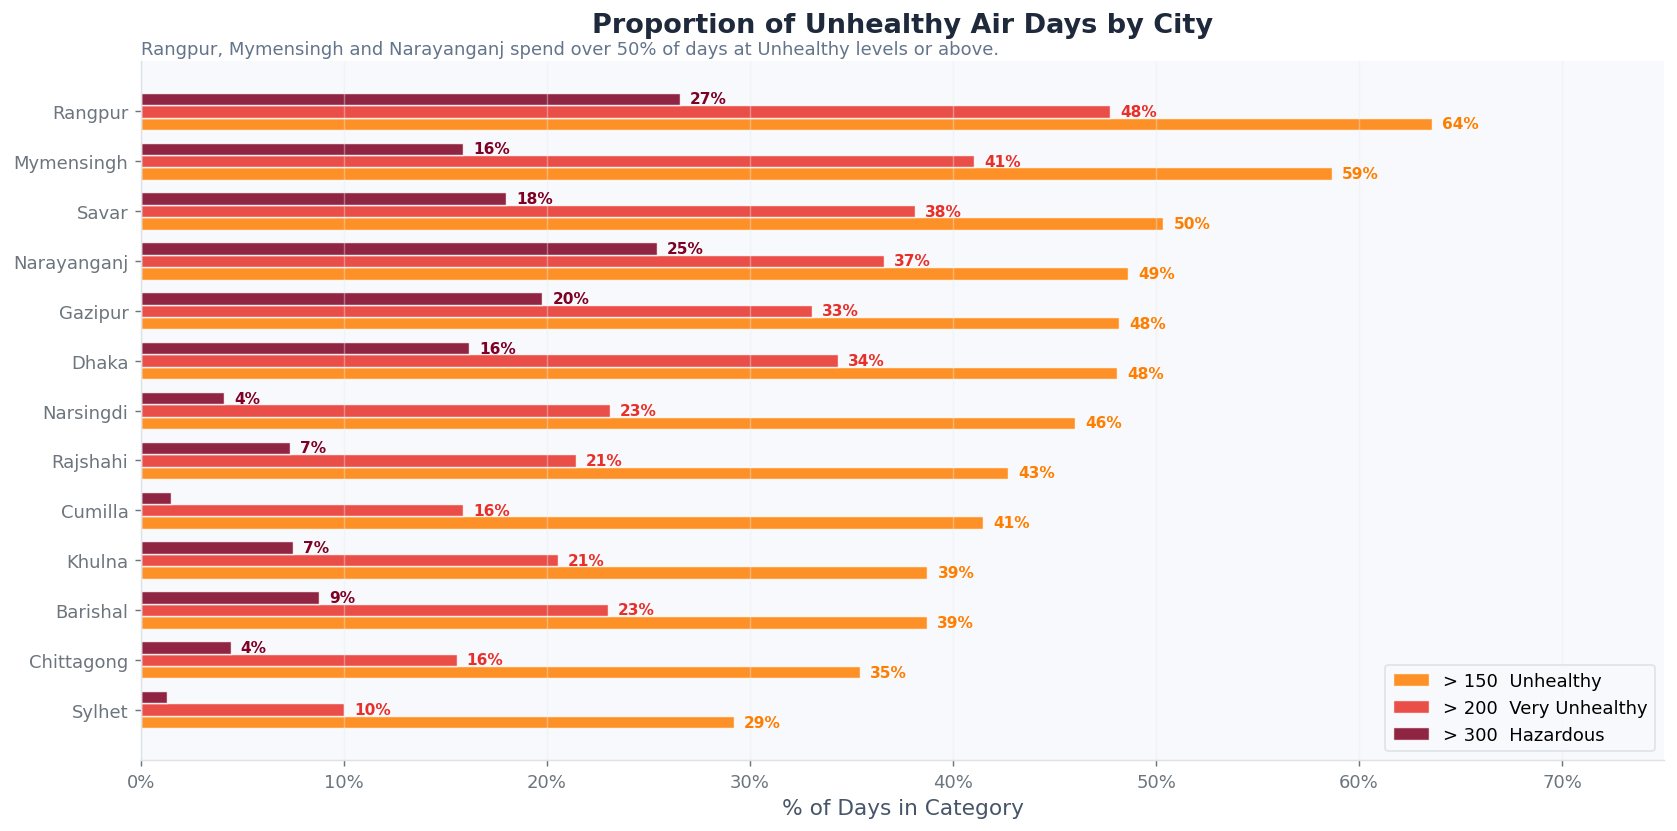

In [12]:
thresholds = {'> 150  Unhealthy': 150, '> 200  Very Unhealthy': 200, '> 300  Hazardous': 300}
city_unhealthy = {}
for label, thresh in thresholds.items():
    city_unhealthy[label] = df.groupby('City').apply(lambda x: (x['AQI'] > thresh).mean() * 100)

unhealthy_df = pd.DataFrame(city_unhealthy)
unhealthy_df = unhealthy_df.sort_values('> 150  Unhealthy', ascending=True)

fig, ax = plt.subplots(figsize=(13, 6.5))
fig.patch.set_facecolor('#ffffff')

y = np.arange(len(unhealthy_df))
h = 0.25
colors_bar = ['#ff7e00', '#e8302a', '#7e0023']

for i, (col, color) in enumerate(zip(unhealthy_df.columns, colors_bar)):
    bars = ax.barh(y + (i - 1) * h, unhealthy_df[col], height=h,
                   color=color, alpha=0.85, label=col, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, unhealthy_df[col]):
        if val > 2:
            ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                    f'{val:.0f}%', va='center', fontsize=8.5, color=color, fontweight='600')

ax.set_yticks(y)
ax.set_yticklabels(unhealthy_df.index, fontsize=10)
ax.set_xlabel('% of Days in Category', fontsize=12, color='#475569')
ax.set_title('Proportion of Unhealthy Air Days by City',
             fontsize=15, fontweight='bold', color=DARK, pad=16)
ax.text(0, 1.01,
        'Rangpur, Mymensingh and Narayanganj spend over 50% of days at Unhealthy levels or above.',
        transform=ax.transAxes, fontsize=10, color='#64748b')
ax.set_facecolor('#f8f9fc')
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='x', alpha=0.4)
ax.set_xlim(0, unhealthy_df.max().max() * 1.18)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig('unhealthy_days.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.8 AQI Distribution by City <a id='5-8'></a>

Box plots reveal the full spread of each city's readings — including outliers and variance — beyond what the mean alone can show.

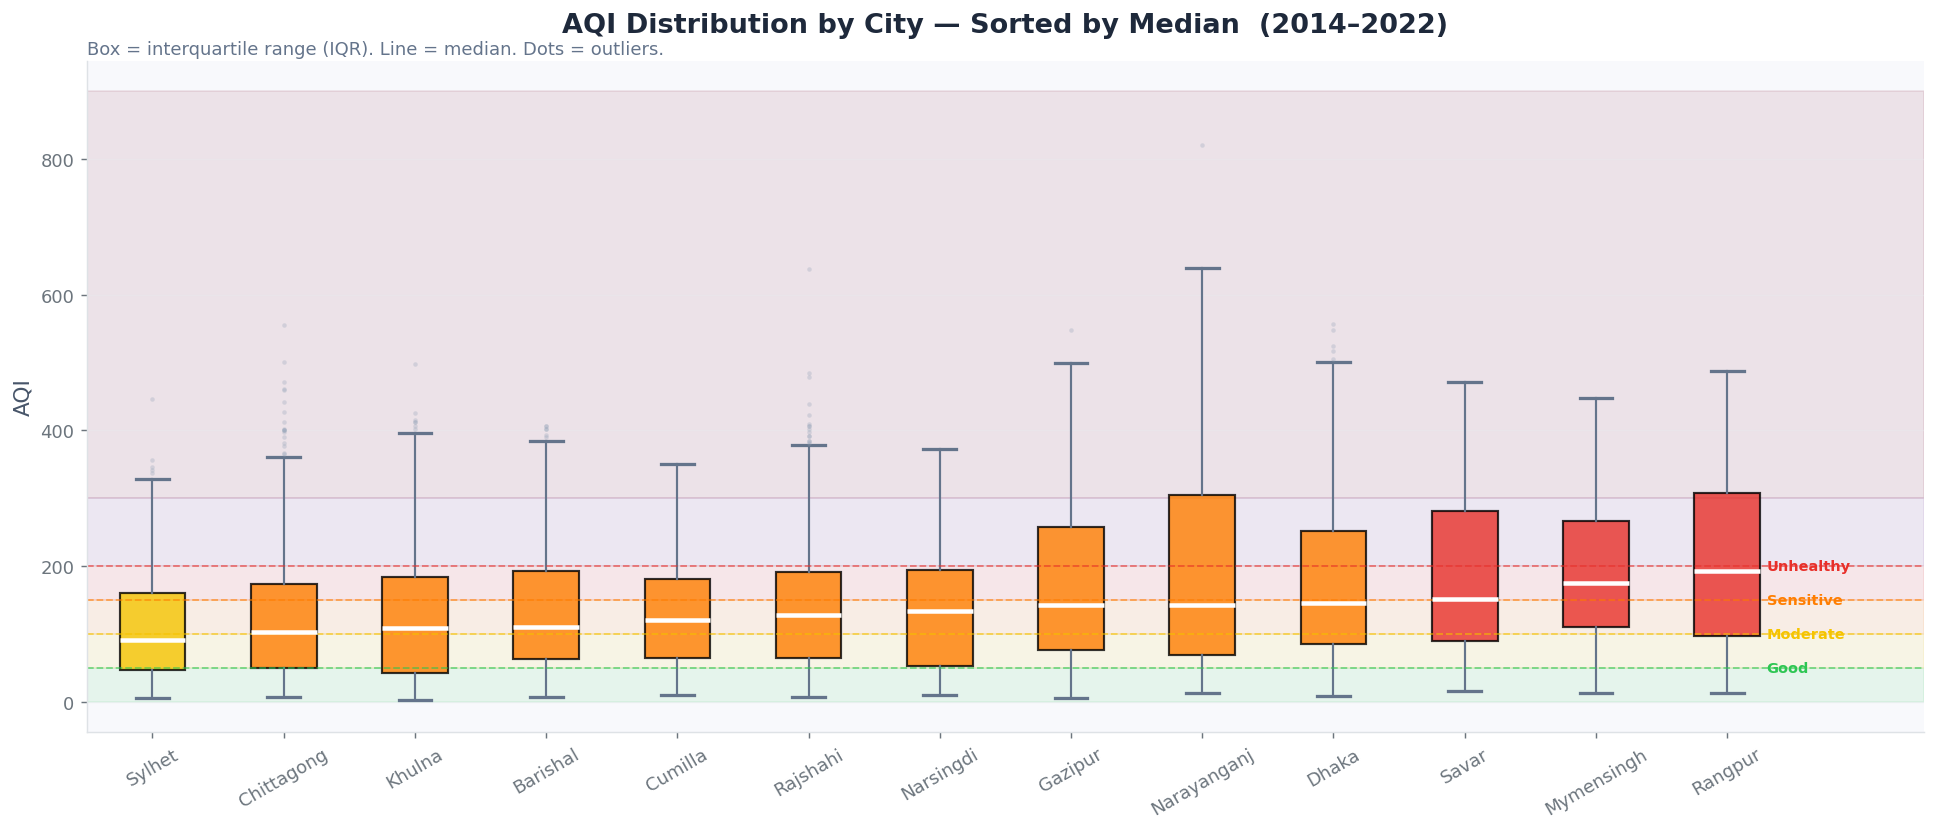

In [13]:
city_order_by_median = df.groupby('City')['AQI'].median().sort_values().index

fig, ax = plt.subplots(figsize=(15, 6.5))
fig.patch.set_facecolor('#ffffff')

# Background category bands
for lo, hi, color in zip([0,50,100,150,200,300],[50,100,150,200,300,900], AQI_PALETTE):
    ax.axhspan(lo, hi, alpha=0.09, color=color, zorder=0)

bp = ax.boxplot(
    [df[df['City'] == city]['AQI'].values for city in city_order_by_median],
    labels=city_order_by_median,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(linewidth=1.2, color='#64748b'),
    capprops=dict(linewidth=1.8, color='#64748b'),
    flierprops=dict(marker='o', markersize=2.5, alpha=0.3,
                    markeredgewidth=0, markerfacecolor='#94a3b8'),
    boxprops=dict(linewidth=1.2),
)

city_colors = [AQI_COLORS[categorize_aqi(df[df['City']==c]['AQI'].median())]
               for c in city_order_by_median]
for patch, color in zip(bp['boxes'], city_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.80)

# WHO threshold lines
for val, label, color in [(50,'Good',AQI_COLORS['Good']),
                           (100,'Moderate',AQI_COLORS['Moderate']),
                           (150,'Sensitive',AQI_COLORS['Unhealthy (Sensitive)']),
                           (200,'Unhealthy',AQI_COLORS['Unhealthy'])]:
    ax.axhline(val, linestyle='--', color=color, linewidth=1, alpha=0.6)
    ax.text(len(city_order_by_median) + 0.3, val, label,
            fontsize=8, color=color, va='center', fontweight='600')

ax.set_title('AQI Distribution by City — Sorted by Median  (2014–2022)',
             fontsize=15, fontweight='bold', color=DARK, pad=16)
ax.text(0, 1.01,
        'Box = interquartile range (IQR). Line = median. Dots = outliers.',
        transform=ax.transAxes, fontsize=10, color='#64748b')
ax.set_ylabel('AQI', fontsize=12, color='#475569')
ax.tick_params(axis='x', rotation=30)
ax.set_facecolor('#f8f9fc')
ax.grid(axis='y', alpha=0.4)
ax.set_xlim(0.5, len(city_order_by_median) + 1.5)

plt.tight_layout()
plt.savefig('aqi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Key Findings <a id='6'></a>

<div style="background:#f8f9fc; border-left:5px solid #6d28d9; padding:24px 28px; border-radius:8px; margin:8px 0;">

### 🏭 1. Air Pollution is a National Crisis
**43% of all readings** across Bangladesh are classified as *Unhealthy or worse* — affecting the general population, not just sensitive groups.

### 🌆 2. Rangpur is the Most Polluted City — Not Dhaka
With a mean AQI of **200.5 (Very Unhealthy)**, Rangpur consistently outranks Dhaka (171.3). This is likely driven by industrial activity, brick kilns, and limited green cover. **Sylhet** (avg 108) is the cleanest.

### ❄️ 3. Seasonality is Extreme and Predictable
January's average AQI of **277 (Hazardous)** is **5× higher** than July's 52 (Good). The monsoon acts as a natural air filter. Any air quality policy must account for this cycle.

### 🦠 4. COVID-19 Lockdowns Had a Limited but Visible Effect
Dhaka's AQI during the **2020 lockdown (Apr–Jun)** was measurably lower than the same period in surrounding years. However, the effect was moderate — Bangladesh's AQI is dominated by seasonal factors more than traffic/industry alone.

### 📈 5. 2021 Was the Worst Year on Record
The national average in 2021 reached **201 AQI** — the only year to cross into the *Very Unhealthy* threshold. This coincided with reduced lockdown mobility data reporting quality and a severe COVID-19 second wave.

### 🔧 6. Sensor Reliability is a Major Data Quality Issue
**Savar was 100% missing in 2021.** Khulna had 94% missing data in 2014. Any analysis of these cities must be interpreted with caution, and investment in sensor infrastructure is critical for policy use.

</div>

---

*Analysis by Mohammed Tahmid Hossain · [saditahmid.github.io](https://saditahmid.github.io) · Related publication: IEEE INCET 2023*